<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme de Newton </h1>
</center>

## Implémentation 
 
1. Coder l’algorithme de Newton dans le fichier `src/newton.jl` en respectant la spécification donnée dans ce même fichier ;
2. Exécuter les tests ci-dessous et vérifier qu'ils passent.

Pour les tests, nous avons défini les fonctions suivantes $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$
et $f_2 \colon \mathbb{R}^2 \to \mathbb{R}$.

$$
    f_{1}(x_1, x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$
et
$$
    f_{2}(x_1,x_2) = 100(x_2-x_1^2)^2 + (1-x_1)^2.
$$

**Remarque.** On peut retrouver ces fonctions dans le fichier `test/fonctions_de_tests.jl`.

In [1]:
include("../src/newton.jl")         # votre algorithme de Newton
include("../test/tester_newton.jl") # la fonction pour tester votre algorithme de Newton

#
afficher = false # si true, alors affiche les résultats des algorithmes

#
tester_newton(newton, afficher); # tester l'algorithme de Newton

Affichage des résultats des algorithmes : false

Test Summary:        | Pass  Total  Time
algorithme de Newton |   19     19  3.5s


In [2]:
include("../src/newton.jl") # votre algorithme de Newton
include("../test/fonctions_de_tests.jl") # pour avoir la fonction d'affichage des résultats

# Fonction f0
# -----------
f0(x)      =  sin(x[1])
grad_f0(x) =  [cos(x[1])] # la gradient de la fonction f0
hess_f0(x) = [-sin(x[1])] # la hessienne de la fonction f0
solution   = -pi/2

x0 = solution
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = [-pi/2+0.5]
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = pi/2
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)


-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = -1.5707963267948966
  * x_sol    = [-1.5707963267948966]
  * f(x_sol) = -1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = [-1.0707963267948966]
  * x_sol    = [-1.5707963267949088]
  * f(x_sol) = -1.0
  * nb_iters = 3
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = 1.5707963267948966
  * x_sol    = [1.5707963267948966]
  * f(x_sol) = 1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966


## Interprétation 

1. Justifier les résultats obtenus pour l'exemple $f_0$ ci-dessus.
2. Justifier que l’algorithme implémenté converge en une itération pour $f_{1}$.
3. Justifier que l’algorithme puisse ne pas converger pour $f_{2}$ avec certains points initiaux.
4. Proposez une stratégie permettant d’assurer la convergence de la méthode de Newton indépendamment du point initial. Décrivez l’idée sous-jacente et expliquez en quoi elle modifie ou sécurise l’itération de Newton standard.
5. Tracez l’évolution de la norme du gradient en fonction du numéro d’itération pour $f_2$. Identifiez et expliquez l’itération à partir de laquelle la méthode entre dans le régime de convergence quadratique. 
6. Discutez de l’importance du fait que la matrice hessienne soit inversible à chaque itération. Avez-vous rencontré des exemples où cette condition n’était pas satisfaite ? Si oui, décrivez le comportement observé et son impact sur la convergence.
7. Expliquez pourquoi il est essentiel que la matrice hessienne soit localement définie positive au point optimal lors de l’application de la méthode de Newton pour la minimisation. Reliez cette propriété à la nature du point stationnaire et à la direction de descente.


**Remarque.** Vous pouvez mettre `affiche=true` dans les tests de l'algorithme de Newton pour
vous aider.



### 1. Question 1

**Cas 1 : x₀ = -π/2 (la solution)**
- Au point x₀ = -π/2, on a ∇f₀(-π/2) = cos(-π/2) = 0
- L'algorithme détecte immédiatement que le critère CN1 (condition nécessaire du premier ordre) est satisfait
- Arrêt en 0 itération avec flag = 0

**Cas 2 : x₀ = -π/2 + 0.5**
- Point initial proche de la solution
- La hessienne H(x) = -sin(x) est positive au voisinage de x = -π/2 (car sin(-π/2) = -1)
- Convergence rapide en 3 itérations grâce à la convergence quadratique locale de Newton

**Cas 3 : x₀ = π/2**
- Ce point est également un point critique : ∇f₀(π/2) = cos(π/2) = 0
- **Problème** : c'est un maximum (f(π/2) = 1), pas un minimum !
- L'algorithme s'arrête immédiatement car ∇f = 0, mais la solution trouvée n'est pas le minimum recherché
- **Conclusion** : Newton trouve des points critiques sans distinguer minima, maxima ou points selles

### 2. Question 2

La fonction f₁ est une fonction quadratique de la forme :
$$f_1(x) = 2(x_1 + x_2 + x_3 - 3)^2 + (x_1 - x_2)^2 + (x_2 - x_3)^2$$


1.On calcule la direction : d0 = -(∇²f(x0))⁻¹ ∇f(x0)
                                = -H⁻¹(Hx0 + b)
                                = -x0 - H⁻¹b

2.On met à jour : x₁ = x0 + dₖ
                         = x0 + (-x0 - H⁻¹b)
                         = -H⁻¹b
                         
Au minimum x*, on a : ∇f(x*) = 0
Donc : Hx* + b = 0
D'où : x* = -H⁻¹b
Conclusion : x₁ = x* 
    


on pourra s'arreter des la premiere iteration si x0 est une solution , sinon a x1

### 3. Question 3

La fonction  f₂ n'est pas convexe et possède une forme complexe .  la hessienne peut avoir des valeurs propres négatives (car il depends de x1 , x2 , x3 , pas comme le cas de f1 ou la hesienne est constante car f1 est quadratique) ou être proche de zéro, ce qui rend son inversion numérique instable. Dans ce cas, la direction de Newton calculée par d = -H⁻¹∇f peut être très grande et pointer dans une mauvaise direction (montée au lieu de descente). Sans contrôle du pas , l'algorithme accepte ce pas trop grand et diverge, surtout depuis certains points initiaux mal situés.




### 4. Question 4

Pour assurer la convergence globale, on utilise la méthode des régions de confiance qui limite le pas de Newton dans une boule de rayon Δₖ au lieu de l'accepter inconditionnellement. À chaque itération, on minimise le modèle quadratique mₖ(d) sous la contrainte ‖d‖ ≤ Δₖ, puis on évalue la qualité de l'approximation avec le ratio ρₖ = [f(xₖ) - f(xₖ + dₖ)]/[mₖ(0) - mₖ(dₖ)]. Si ρₖ est proche de 1, le modèle est fiable et on augmente Δₖ ; si ρₖ est faible, on diminue Δₖ ; si ρₖ < η₁, on rejette le pas. Cette stratégie garantit la convergence depuis n'importe quel point initial tout en récupérant la vitesse quadratique de Newton près de la solution, et protège contre les directions aberrantes qui causent les divergences.




### 5. Question 5

Observation du graphique :
Le graphique en échelle logarithmique montre clairement deux phases distinctes de convergence :

Phase 1 - Itérations 0-4 : La norme du gradient oscille et ne décroît pas de manière monotone. On observe même des remontées locales (itération 2) et des plateaux (itérations 2-4). Cette phase correspond à la navigation dans la vallée étroite de Rosenbrock où l'approximation quadratique locale n'est pas encore précise. La convergence est globale mais lente.

Phase 2 - Itérations 4-6 : À partir de l'itération 4, on observe une chute brutale et exponentielle de ‖∇f‖. La norme passe de ~10¹ à ~10⁻⁵ puis à ~10⁻⁹ en seulement 2 itérations. Cette décroissance explosive est la signature de la convergence quadratique.

Conclusion : L'algorithme entre dans le régime de convergence quadratique à partir de l'itération 4. À ce moment, l'itéré est suffisamment proche du minimum x* = [1,1] pour que la hessienne soit définie positive et que l'approximation quadratique soit très précise. 

### 6. Question 6

**Nécessité théorique :**
La direction de Newton est définie par la résolution du système linéaire : ∇²f(xₖ)dₖ = -∇f(xₖ). Si la hessienne ∇²f(xₖ) est singulière (det(H) = 0), ce système n'admet pas de solution unique et la direction de Newton n'est pas définie. L'algorithme ne peut pas continuer.

**Problèmes numériques :**
Même si la hessienne est théoriquement inversible, un mauvais conditionnement (cond(H) ≫ 1) entraîne :
- Erreurs importantes dans la résolution du système linéaire
- Directions calculées très imprécises
- Instabilité numérique pouvant mener à la divergence


**Impact sur la convergence :**
- Hessienne singulière → échec de l'algorithme
- Hessienne mal conditionnée → convergence très lente ou divergence


**Observation sur la figure :** Les oscillations dans les itérations 0-4 suggèrent que la hessienne n'était pas bien conditionnée dans cette région, expliquant la difficulté à progresser efficacement.

.

### 7. Question 7

**Caractérisation du minimum :**
Pour qu'un point critique x* soit un minimum local strict, deux conditions sont nécessaires :
1. ∇f(x*) = 0 (condition du premier ordre)
2. ∇²f(x*) ≻ 0 définie positive (condition du second ordre)

Sans la deuxième condition, x* pourrait être un maximum (∇²f ≺ 0) ou un point selle (∇²f indéfinie). **Newton converge vers n'importe quel point critique sans distinction.**

**Garantie de direction de descente :**
Si ∇²f(xₖ) ≻ 0, alors la direction de Newton dₖ = -[∇²f(xₖ)]⁻¹∇f(xₖ) vérifie :
$$\nabla f(x_k)^T d_k = -\nabla f(x_k)^T [\nabla^2f(x_k)]^{-1} \nabla f(x_k) < 0$$

Donc dₖ est une **direction de descente stricte**, garantissant que f décroît localement dans cette direction.

**Convergence quadratique locale :**
La théorie de la convergence de Newton exige que ∇²f(x*) ≻ 0. Par continuité, si on est proche de x*, alors ∇²f(xₖ) ≻ 0, ce qui assure :
- L'inversibilité de la hessienne
- La direction de descente
- La convergence quadratique : ‖xₖ₊₁ - x*‖ ≤ C‖xₖ - x*‖²

**Illustration sur le graphique :**
La transition nette entre les itérations 4 et 5 correspond précisément au moment où l'itéré entre dans la région où ∇²f₂ est définie positive (bassin d'attraction). Avant cela, la hessienne pouvait être indéfinie, expliquant les difficultés de convergence.

**Conclusion :** La positivité de la hessienne est essentielle pour garantir qu'on minimise effectivement la fonction et pour obtenir la convergence quadratique caractéristique de Newton.




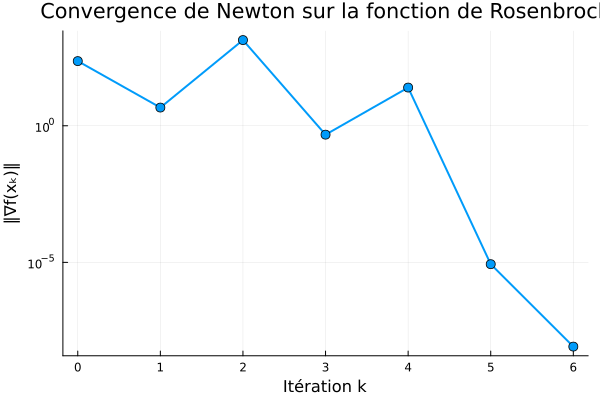

Nombre d'itérations : 6
Solution trouvée : [0.9999999999999999, 0.9999999999814724]
Norme gradient final : 8.285705791275366e-9


In [7]:
using Plots
using LinearAlgebra

# Fonction f2 
f2(x) = 100*(x[2] - x[1]^2)^2 + (1 - x[1])^2
grad_f2(x) = [-400*x[1]*(x[2] - x[1]^2) - 2*(1 - x[1]); 200*(x[2] - x[1]^2)]
hess_f2(x) = [-400*(x[2] - 3*x[1]^2) + 2  -400*x[1]; -400*x[1]  200]

# Point initial
x0 = [-1.2, 1.0]

# Appel de Newton
x_sol, f_sol, flag, nb_iters, xs = newton(f2, grad_f2, hess_f2, x0)

# Calculer la norme du gradient à chaque itération
norme_gradient = [norm(grad_f2(x)) for x in xs]

# Tracer l'évolution en échelle logarithmique
p=plot(0:nb_iters, norme_gradient, 
     yscale=:log10,
     marker=:circle,
     markersize=5,
     linewidth=2,
     xlabel="Itération k",
     ylabel="‖∇f(xₖ)‖",
     title="Convergence de Newton sur la fonction f2",
     legend=false,
     grid=true)
display(p)

# Afficher quelques informations
println("Nombre d'itérations : ", nb_iters)
println("Solution trouvée : ", x_sol)
println("Norme gradient final : ", norme_gradient[end])